In [1]:
import math
import random
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [2]:
@dataclass
class CFG:
    data_root: str = "./data"
    batch_size: int = 128
    lr: float = 1e-3
    epochs: int = 20  
    latent_dim: int = 16  # 隐变量维度
    cond_dim: int = 10    # 条件(one-hot)维度：MNIST 0-9
    beta: float = 1.0     # KL 最终权重（=1 即标准VAE）
    beta_warmup_epochs: int = 5  # 前N个epoch线性warm-up到beta
    num_workers: int = 2
    pin_memory: bool = True

cfg = CFG()


## 1) 数据加载：加载完整 MNIST (0-9)

In [3]:
transform = transforms.ToTensor()  # 输出为 [0,1]

train_ds = datasets.MNIST(root=cfg.data_root, train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root=cfg.data_root, train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and (device.type == 'cuda'),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and (device.type == 'cuda'),
)

def one_hot(y: torch.Tensor, num_classes: int) -> torch.Tensor:
    return F.one_hot(y, num_classes=num_classes).float()

xb, yb = next(iter(train_loader))
xb.shape, yb.unique()


(torch.Size([128, 1, 28, 28]), tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

## 2) 定义 Conditional VAE

- 输入：`(B,1,28,28)` 和 `(B,)`
- Encoder 输入：拼接图像与条件图，输出 `mu, logvar`，shape `(B, latent_dim)`
- Decoder 输入：拼接 `z` 与条件向量，输出 `recon`，shape `(B,1,28,28)`，范围 `[0,1]`

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim: int, cond_dim: int):
        super().__init__()
        self.cond_dim = cond_dim
        # 输入通道数 = 图像通道(1) + 条件维度(cond_dim)
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1 + cond_dim, out_channels=32, kernel_size=4, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),            # 14x14 -> 7x7
            nn.ReLU(inplace=True),
            nn.Flatten(),
        )
        # 输出均值和对数方差
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x, y_onehot):
        # 将条件向量扩展为特征图大小: (B, cond_dim) -> (B, cond_dim, 28, 28)
        y_map = y_onehot[:, :, None, None].expand(-1, -1, x.size(2), x.size(3))
        # 在通道维度拼接图像和条件图: (B, 1+cond_dim, 28, 28)
        x_in = torch.cat([x, y_map], dim=1)
        h = self.net(x_in)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim: int, cond_dim: int):
        super().__init__()
        # 输入: 隐变量 z + 条件向量 y
        self.fc = nn.Linear(latent_dim + cond_dim, 64 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # 14x14 -> 28x28
        )

    def forward(self, z, y_onehot):
        # 拼接 z 和 y: (B, latent_dim + cond_dim)
        zy = torch.cat([z, y_onehot], dim=1)
        # 映射回特征图形状: (B, 64, 7, 7)
        h = self.fc(zy).view(z.size(0), 64, 7, 7)
        return self.net(h)  # 输出 logits (未经过 sigmoid)


class VAE(nn.Module):
    def __init__(self, latent_dim: int, cond_dim: int):
        super().__init__()
        self.cond_dim = cond_dim
        self.encoder = Encoder(latent_dim=latent_dim, cond_dim=cond_dim)
        self.decoder = Decoder(latent_dim=latent_dim, cond_dim=cond_dim)

    @staticmethod
    def reparameterize(mu, logvar):
        # 重参数化技巧: z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x, y):
        # 将标签转换为 one-hot 向量
        y_onehot = one_hot(y, self.cond_dim).to(x.device)
        # 编码: 获取分布参数
        mu, logvar = self.encoder(x, y_onehot)
        # 采样
        z = self.reparameterize(mu, logvar)
        # 解码: 生成重构图像 logits
        x_logits = self.decoder(z, y_onehot)
        return x_logits, mu, logvar


model = VAE(latent_dim=cfg.latent_dim, cond_dim=cfg.cond_dim).to(device)
sum(p.numel() for p in model.parameters())


256865

## 3) 损失函数：重构损失 + KL

- 重构损失：`BCE(x_recon, x)`，按像素求和再对 batch 取均值
- KL：`-0.5 * sum(1 + logvar - mu^2 - exp(logvar))`，对 batch 取均值

In [5]:
def vae_losses(x, x_logits, mu, logvar, beta: float = 1.0):
    # recon: sum over pixels, mean over batch
    recon = F.binary_cross_entropy_with_logits(x_logits, x, reduction='none')
    recon = recon.flatten(1).sum(dim=1).mean()
    # KL: mean over batch
    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    kl = kl_per_sample.mean()

    loss = recon + beta * kl
    return loss, recon, kl


## 4) 训练与评估循环

记录每个 epoch：
- `train_recon`, `train_kl`, `train_total`
- `test_recon`（测试集重构能力）

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

history = {
    'train_total': [],
    'train_recon': [],
    'train_kl': [],
    'test_recon': [],
}

def get_beta(epoch: int) -> float:
    # 线性warmup：让KL在训练早期有更合理的动态
    if cfg.beta_warmup_epochs <= 0:
        return cfg.beta
    t = min(1.0, epoch / cfg.beta_warmup_epochs)
    return cfg.beta * t

def run_epoch_train(model, loader, epoch: int):
    model.train()
    tot_loss = 0.0
    tot_recon = 0.0
    tot_kl = 0.0
    n = 0
    beta = get_beta(epoch)

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        x_logits, mu, logvar = model(x, y)
        loss, recon, kl = vae_losses(x, x_logits, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        tot_loss += loss.item() * bs
        tot_recon += recon.item() * bs
        tot_kl += kl.item() * bs
        n += bs

    return tot_loss / n, tot_recon / n, tot_kl / n , beta


@torch.no_grad()
def run_epoch_test(model, loader, epoch: int):
    model.eval()
    tot_recon = 0.0
    n = 0
    beta = get_beta(epoch)
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        x_logits, mu, logvar = model(x, y)
        _, recon, _ = vae_losses(x, x_logits, mu, logvar, beta=beta)
        bs = x.size(0)
        tot_recon += recon.item() * bs
        n += bs
    return tot_recon / n


for epoch in range(1, cfg.epochs + 1):
    train_total, train_recon, train_kl, beta = run_epoch_train(model, train_loader, epoch)
    test_recon = run_epoch_test(model, test_loader, epoch)

    history['train_total'].append(train_total)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['test_recon'].append(test_recon)

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"beta={beta:.2f} | "
        f"train_total={train_total:>6.2f} recon={train_recon:>6.2f} kl={train_kl:>5.2f} | "
        f"test_recon={test_recon:>6.2f} | "
    )
    

Epoch 01/20 | beta=0.20 | train_total=136.17 recon=128.85 kl=36.63 | test_recon= 86.59 | 
Epoch 02/20 | beta=0.40 | train_total= 97.37 recon= 84.81 kl=31.39 | test_recon= 80.18 | 
Epoch 03/20 | beta=0.60 | train_total= 97.73 recon= 81.34 kl=27.31 | test_recon= 78.92 | 
Epoch 04/20 | beta=0.80 | train_total=100.07 recon= 80.83 kl=24.05 | test_recon= 78.94 | 
Epoch 05/20 | beta=1.00 | train_total=102.86 recon= 81.26 kl=21.60 | test_recon= 79.93 | 
Epoch 06/20 | beta=1.00 | train_total=101.62 recon= 80.31 kl=21.31 | test_recon= 79.45 | 
Epoch 07/20 | beta=1.00 | train_total=100.66 recon= 79.48 kl=21.17 | test_recon= 78.18 | 
Epoch 08/20 | beta=1.00 | train_total= 99.93 recon= 78.83 kl=21.10 | test_recon= 77.91 | 
Epoch 09/20 | beta=1.00 | train_total= 99.25 recon= 78.24 kl=21.01 | test_recon= 77.92 | 
Epoch 10/20 | beta=1.00 | train_total= 98.77 recon= 77.83 kl=20.94 | test_recon= 77.41 | 
Epoch 11/20 | beta=1.00 | train_total= 98.27 recon= 77.44 kl=20.83 | test_recon= 77.22 | 
Epoch 12/2

## 5) 损失曲线可视化

- 训练集重构损失与 KL
- 测试集重构损失

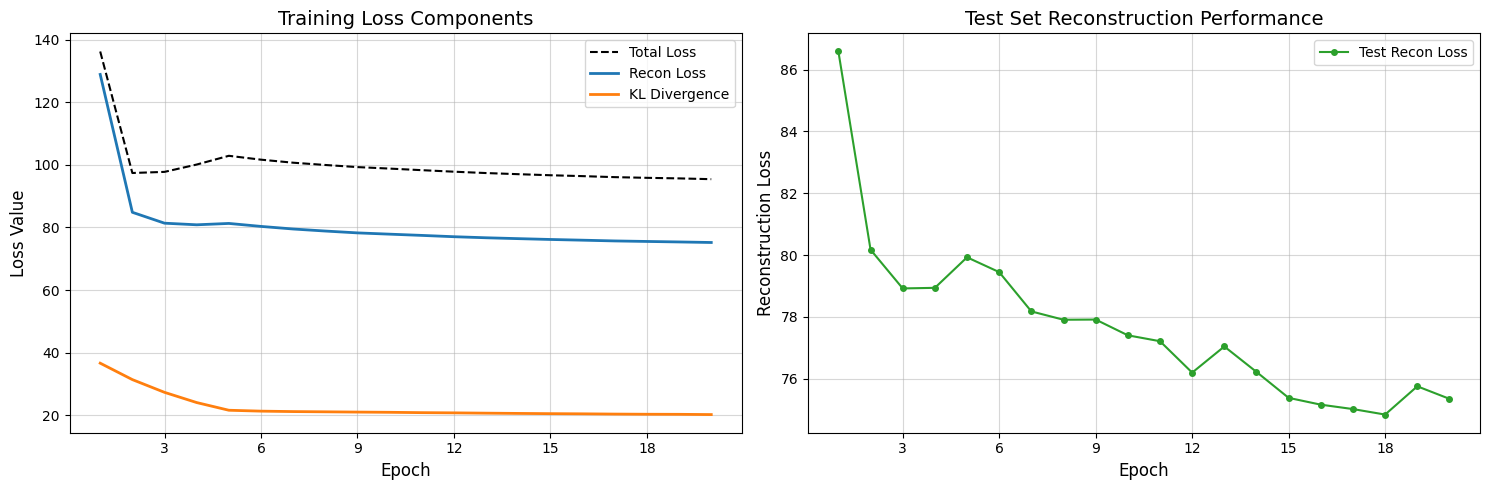

In [7]:
from matplotlib.ticker import MaxNLocator

epochs = np.arange(1, cfg.epochs + 1)

plt.figure(figsize=(15, 5))

# Subplot 1: Train Losses (Total, Recon, KL)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(epochs, history['train_total'], label='Total Loss', color='black', linestyle='--', linewidth=1.5)
ax1.plot(epochs, history['train_recon'], label='Recon Loss', color='tab:blue', linewidth=2)
ax1.plot(epochs, history['train_kl'], label='KL Divergence', color='tab:orange', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.set_title('Training Loss Components', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.5)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks

# Subplot 2: Test Reconstruction Loss
ax2 = plt.subplot(1, 2, 2)
ax2.plot(epochs, history['test_recon'], label='Test Recon Loss', color='tab:green', marker='o', markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Reconstruction Loss', fontsize=12)
ax2.set_title('Test Set Reconstruction Performance', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.5)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer ticks

plt.tight_layout()
plt.show()


## 6) 重构效果展示（训练/测试各取少量样本）

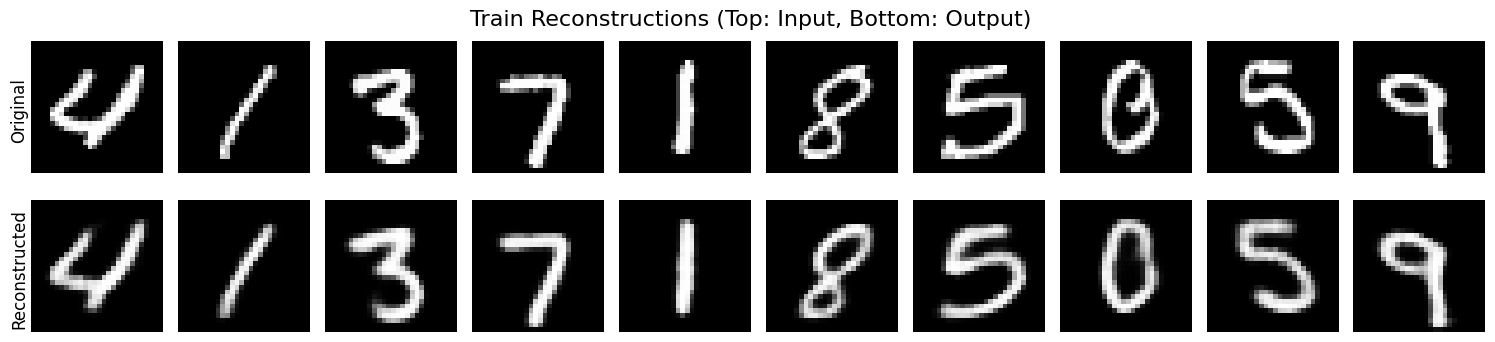

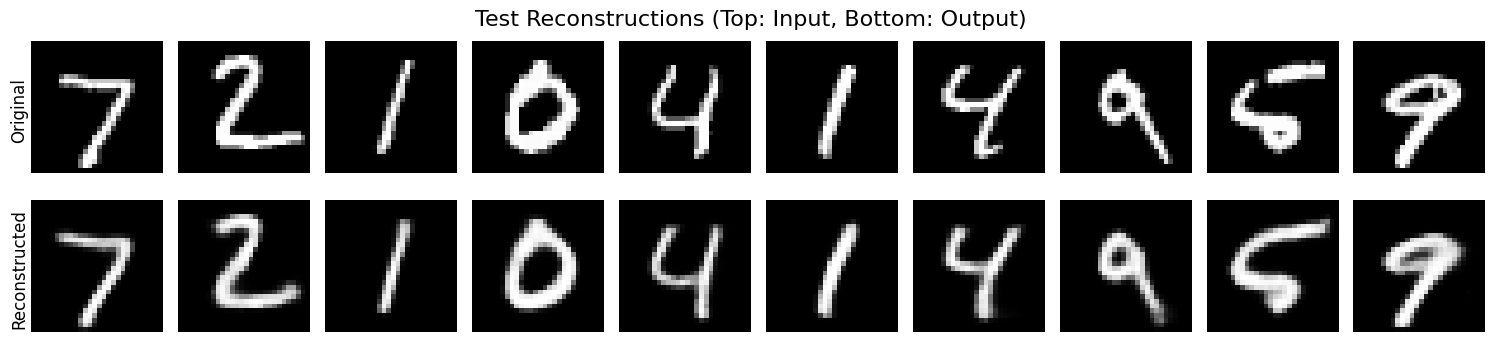

In [8]:
@torch.no_grad()
def show_reconstructions(model, loader, title: str, n: int = 8):
    model.eval()
    x, y = next(iter(loader))
    x = x[:n].to(device)
    y = y[:n].to(device)

    x_logits, _, _ = model(x, y)
    x_recon = torch.sigmoid(x_logits)

    x = x.cpu().numpy()
    x_recon = x_recon.cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 4))
    for i in range(n):
        ax_orig = axes[0, i]
        ax_orig.imshow(x[i, 0], cmap='gray')
        ax_orig.axis('off')

        ax_recon = axes[1, i]
        ax_recon.imshow(x_recon[i, 0], cmap='gray')
        ax_recon.axis('off')

    axes[0, 0].text(-5, 14, "Original", fontsize=12, va='center', rotation=90)
    axes[1, 0].text(-5, 14, "Reconstructed", fontsize=12, va='center', rotation=90)

    plt.suptitle(title, fontsize=16, y=0.9)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, train_loader, title='Train Reconstructions (Top: Input, Bottom: Output)', n=10)
show_reconstructions(model, test_loader, title='Test Reconstructions (Top: Input, Bottom: Output)', n=10)


## 7) 潜空间随机采样生成新数字图像

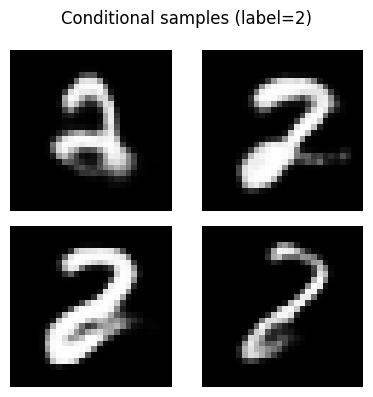

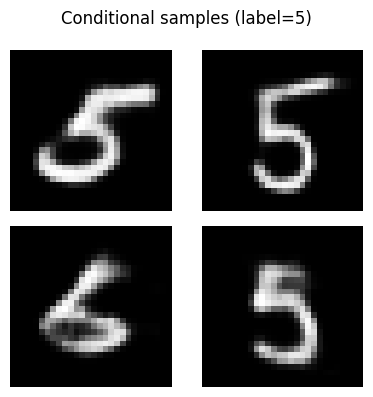

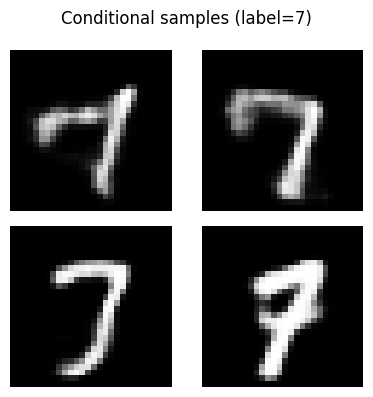

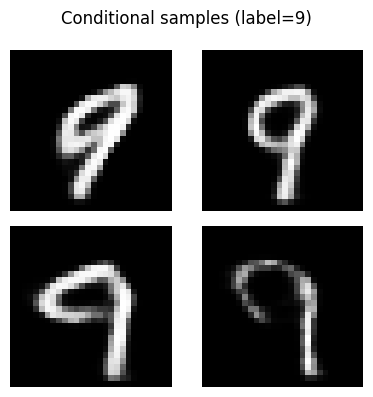

In [9]:
@torch.no_grad()
def generate_by_label(model, label: int, n: int = 4):
    model.eval()
    z = torch.randn(n, cfg.latent_dim, device=device)
    y = torch.full((n,), int(label), device=device, dtype=torch.long)
    y_onehot = one_hot(y, cfg.cond_dim).to(device)

    x_logits = model.decoder(z, y_onehot)
    x_gen = torch.sigmoid(x_logits).cpu().numpy()

    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(2 * cols, 2 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(x_gen[i, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Conditional samples (label={label})')
    plt.tight_layout()
    plt.show()

generate_by_label(model, label=2, n=4)
generate_by_label(model, label=5, n=4)
generate_by_label(model, label=7, n=4)
generate_by_label(model, label=9, n=4)
